In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

In [ ]:
#WGS84 Constants
a = 6378.137  # Earth's equatorial radius in km
e2 = 0.00669437999014  # Earth's eccentricity squared

lat = 7.6268648
lon = 5.1851236 #My home coordinates
height = 444.2803158 / 1000  # Height in meters

# Convert latitude and longitude from degrees to radians
lat_rad = np.radians(lat)
lon_rad = np.radians(lon)
#
N = a / np.sqrt(1 - e2 * np.sin(lat_rad)**2)

# Convert to ECEF coordinates
x_ecef = (N + height) * np.cos(lat_rad) * np.cos(lon_rad) #
y_ecef = (N + height) * np.cos(lat_rad) * np.sin(lon_rad)
z_ecef = (N * (1 - e2) + height) * np.sin(lat_rad)

In [9]:
from astropy.time import Time
from astropy.coordinates import ITRS, TEME
from astropy import units as u

# Convert using astropy
ecef = ITRS(x=x_ecef*u.km, y=y_ecef*u.km, z=z_ecef*u.km, 
            obstime=Time(datetime.now()))
eci = ecef.transform_to(TEME(obstime=ecef.obstime))

x_eci = eci.x.to(u.km).value
y_eci = eci.y.to(u.km).value
z_eci = eci.z.to(u.km).value

print(f"ECEF Coordinates: x={x_ecef:.2f} km, y={y_ecef:.2f} km, z={z_ecef:.2f} km")
print(f"ECI Coordinates: x={x_eci:.2f} km, y={y_eci:.2f} km, z={z_eci:.2f} km")

ECEF Coordinates: x=6296.65 km, y=571.39 km, z=840.96 km
ECI Coordinates: x=-3678.63 km, y=-5142.18 km, z=840.96 km


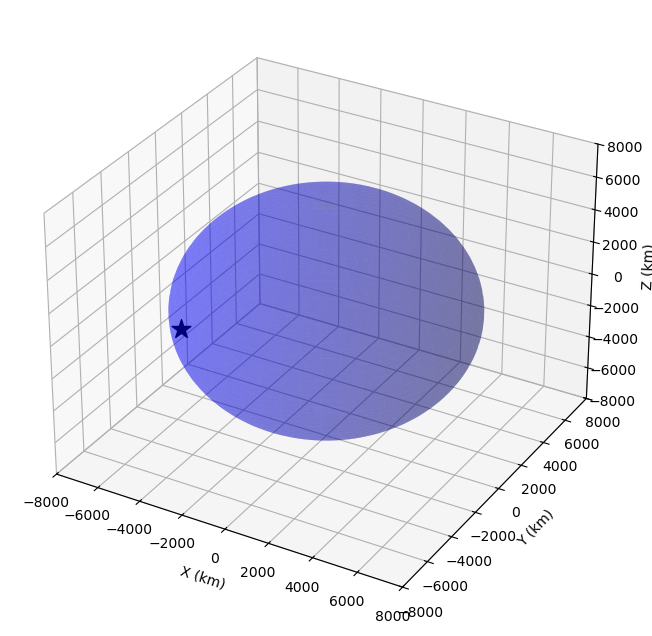

In [ ]:
#plotting my home on the globe;

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.set_xlim([-8000, 8000])
ax.set_ylim([-8000, 8000])
ax.set_zlim([-8000, 8000])
ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.set_zlabel('Z (km)')

u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 50)
x = 6371 * np.outer(np.cos(u), np.sin(v))
y = 6371 * np.outer(np.sin(u), np.sin(v))
z = 6371 * np.outer(np.ones(np.size(u)), np.cos(v))

ax.plot_surface(x, y, z, color='b', alpha=0.3)
  
ax.scatter(x_eci, y_eci, z_eci, label= "My home", color = 'black',s = 200, marker='*')


plt.show()